In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser  # type: ignore
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from copy import deepcopy

sys.path.append('.')
from toroidal_coordinates.toroidal_lifting import toroidal_lifting_distance, toroidal_lifting_distance_upgrade
from toroidal_coordinates.Gardner_toroidal import Gardner_coord
from toroidal_coordinates.dreimac_toroidal import compute_toroidal_coords_dreimac
from toroidal_coordinates.compute_coord import visualize_tor_coords_x_traj, interp_arr
from utils import get_spikes, fit_para, toroidal_alignment, plot_barcode, get_ratemaps
from persistence_homology import computeDistanceMatrix
from toroidal_coordinates.epsilon import compute_epsilon
from Gardner_data_test.Gardner_lifting_test import gaussian_smooth_toroidal, interpolate_2d_along_axis_0
from constants import *

In [4]:
def Gardner_coord_temp(interp10: bool = False, config: None | tuple[str, str, str, str] = None, epsilon: None | float = None, smooth: bool = True):
    folder = 'Toroidal_topology_grid_cell_data/'

    if config is None:
        rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')
    else:
        rat_name, mod_name, sess_name, day_name = config
    if sess_name in ('OF','WW'):
        sspikes,xx,yy, _, _ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                         bSmooth = True, bSpeed = True, folder = folder )
    else:
        sspikes = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                             bSmooth = True, bSpeed = False, folder = folder )
        
    if interp10:
        sspikes = interpolate_2d_along_axis_0(sspikes, sspikes.shape[0]*10) # makes sspikes 10 times longer

    # coords, times = compute_toroidal_coords_dreimac(d, standard_range=False, distance_matrix=True)
    coords, times, _, _ = Gardner_coord(sspikes)

    compute_epsilon(coords, plot=True)
    plt.show()

    if sess_name in ('OF','WW'):
        xx = interp_arr(xx, coords.shape[0])
        yy = interp_arr(yy, coords.shape[0])
        times = np.arange(xx.shape[0])
        visualize_tor_coords_x_traj(xx, yy, coords, times)

    # coordsbox, times_box, centcosall, centsinall = Gardner_coord(sspikes, xx, yy)
    # print(coords.shape, times.shape, xx.shape, yy.shape)
    # import pdb; pdb.set_trace()
    lifted_coords = toroidal_lifting_distance_upgrade(coords, epsilon=epsilon)

    smooth_factor = 10
    if interp10:
        smooth_factor = 100
    
    if smooth:
        lifted_coords[:, 0] = gaussian_filter1d(lifted_coords[:, 0], smooth_factor)
        lifted_coords[:, 1] = gaussian_filter1d(lifted_coords[:, 1], smooth_factor)

    if sess_name in ('OF','WW'):
        original_coords = np.concatenate([xx[:, None], yy[:, None]], axis=1)
        return lifted_coords, original_coords
    else:
        return lifted_coords

/home/yyao01/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:119: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


4.1866810774054475


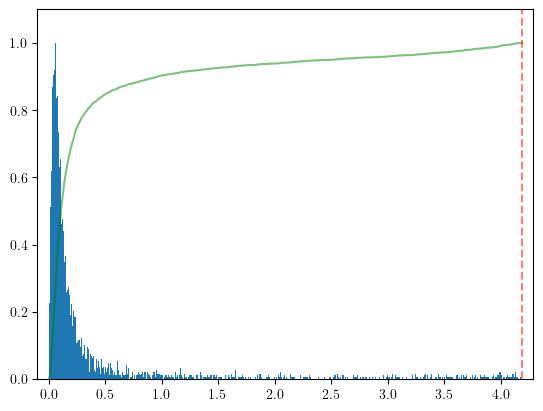

(206182, 2)
4.1866810774054475


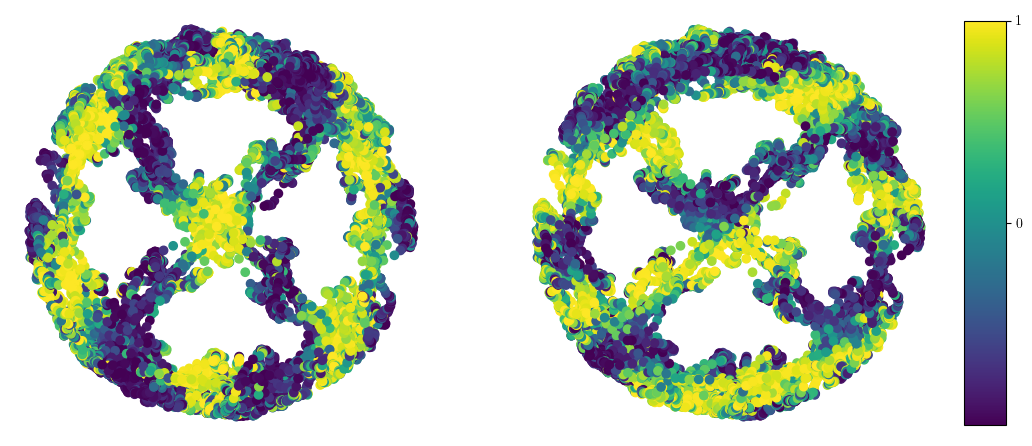

In [5]:
config = ('R', '2', 'WW', 'day1')
lifted, original = Gardner_coord_temp(interp10=False, config=config, smooth=True)

In [6]:
original.shape, lifted.shape

((206182, 2), (206182, 2))

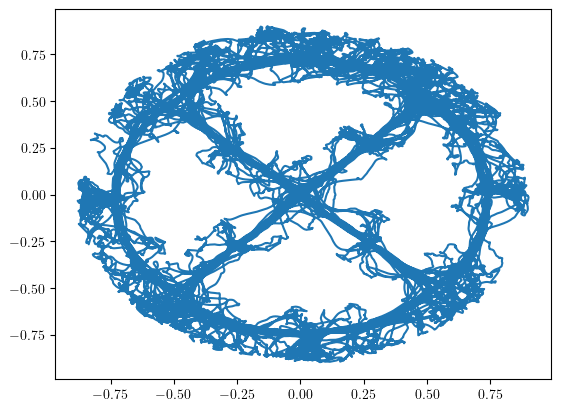

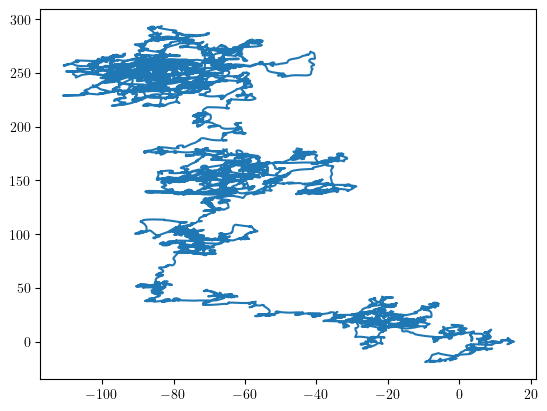

In [7]:
plt.plot(original[:, 0], original[:, 1])
plt.show()

plt.plot(lifted[:, 0], lifted[:, 1])
plt.show()

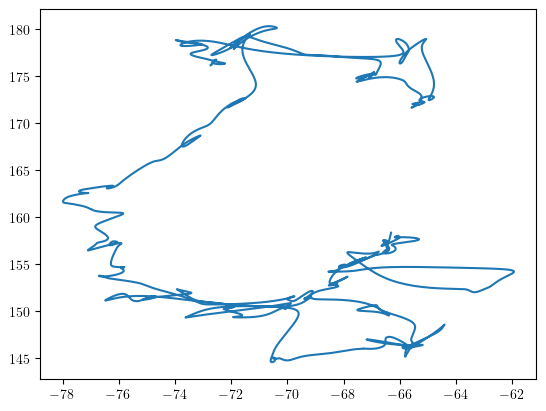

In [8]:
t1 = 110000
t2 = t1 + 5000
plt.plot(lifted[t1:t2, 0], lifted[t1:t2, 1])
plt.show()

In [9]:
folder = 'Toroidal_topology_grid_cell_data/'

rat_name, mod_name, sess_name, day_name = ('R', '2', 'WW', 'day1')
if sess_name in ('OF','WW'):
    sspikes,xx,yy, _, _ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                        bSmooth = True, bSpeed = True, folder = folder )
else:
    sspikes = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                            bSmooth = True, bSpeed = False, folder = folder )
    

# coords, times = compute_toroidal_coords_dreimac(d, standard_range=False, distance_matrix=True)
coords, times, _, _ = Gardner_coord(sspikes)



/home/yyao01/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:119: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


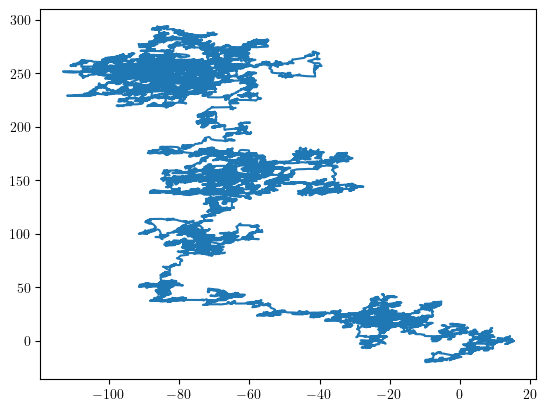

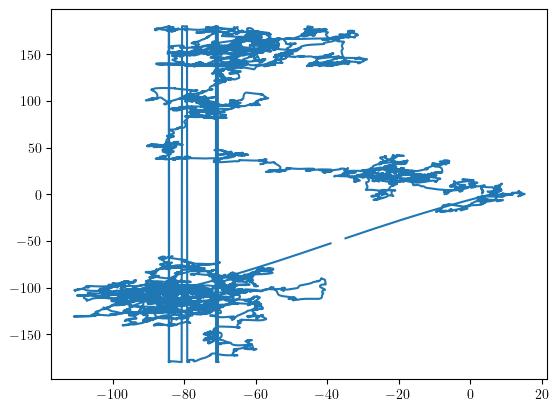

In [10]:
lifted0 = toroidal_lifting_distance_upgrade(coords, epsilon=4)
plt.figure()
plt.plot(lifted0[:, 0], lifted0[:, 1])
plt.show()

smoothed_lifted0 = deepcopy(lifted0)
smoothed_lifted0[:, 0] = gaussian_smooth_toroidal(smoothed_lifted0[:, 0], 10)
smoothed_lifted0[:, 1] = gaussian_smooth_toroidal(smoothed_lifted0[:, 1], 10)
plt.figure()
plt.plot(smoothed_lifted0[:, 0], smoothed_lifted0[:, 1])
plt.show()

# FIXME: Smooth is working unexpectedly

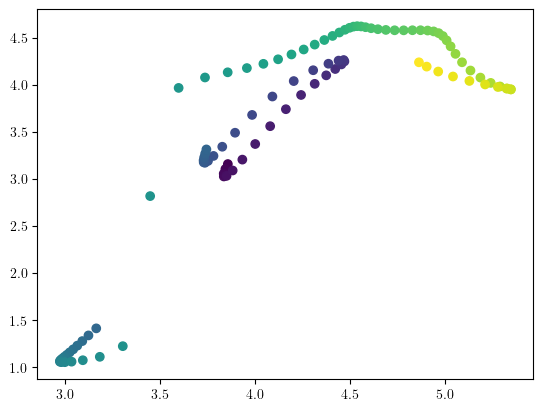

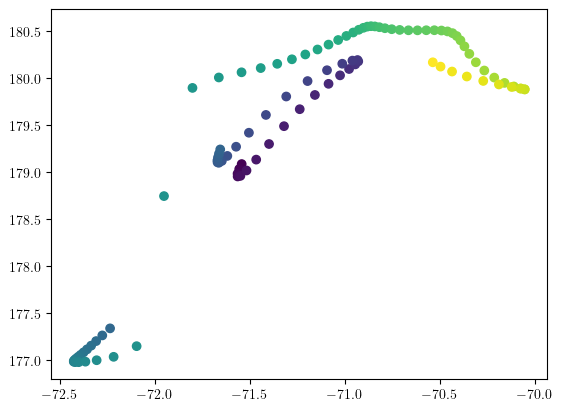

In [11]:
start = 113600
end = start + 100
colors = plt.cm.viridis(np.linspace(0, 1, end-start))

plt.figure()
plt.scatter(coords[start:end, 0], coords[start:end, 1], marker='o', c=colors)
plt.figure()
plt.scatter(lifted0[start:end, 0], lifted0[start:end, 1], marker='o', c=colors)
plt.show()

In [12]:
from affine_transform.get_transform_mat import get_transform_mat, apply_transform_mat
from affine_transform.score_mismatch import score_mismatch, compute_mean_transform_mat
np.random.seed(0)
len_seg = 2000
colors = plt.cm.viridis(np.linspace(0, 1, len_seg))

104


/tmp/ipykernel_1259311/1792604699.py:4: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  all_original = np.array([original[i*len_seg:(i+1)*len_seg] for i in range(num_seg)])
/tmp/ipykernel_1259311/1792604699.py:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  all_lifted = np.array([lifted[i*len_seg:(i+1)*len_seg] for i in range(num_seg)])
/tmp/ipykernel_1259311/1792604699.py:16: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may con

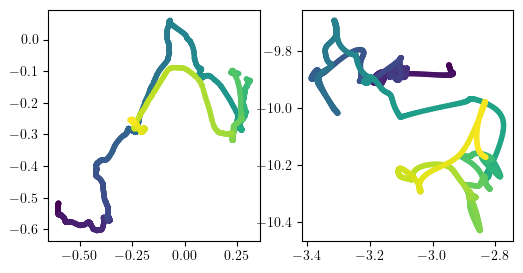

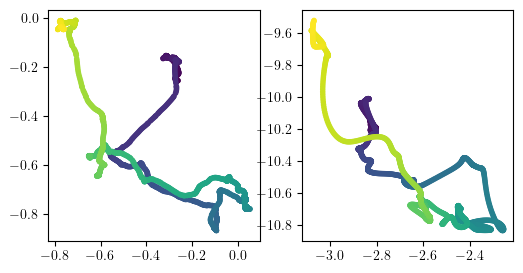

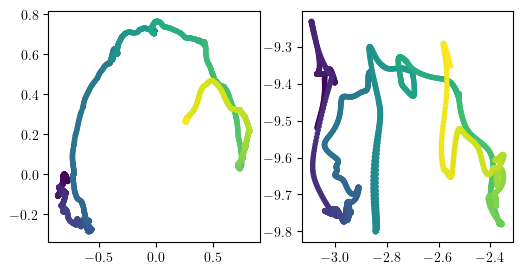

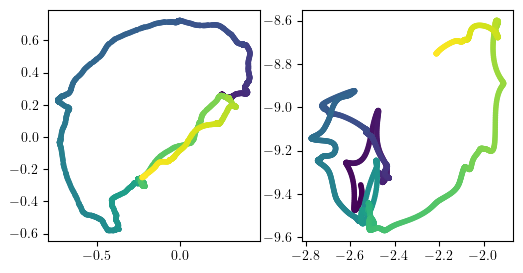

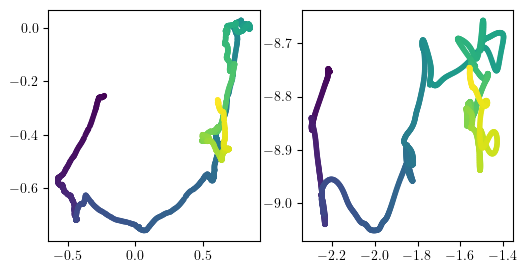

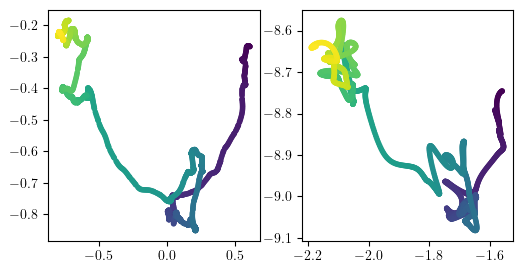

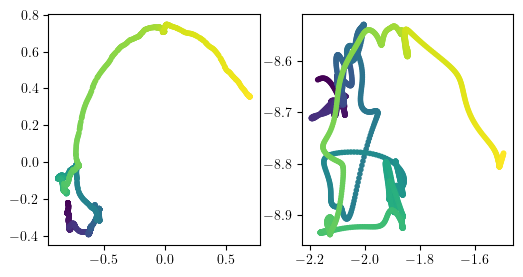

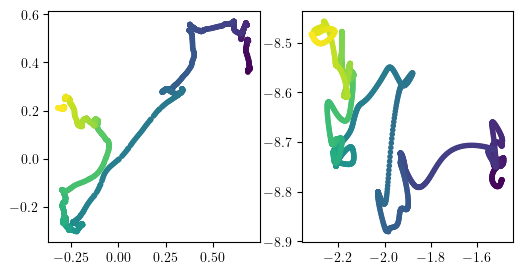

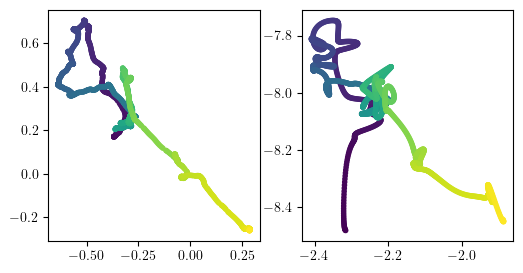

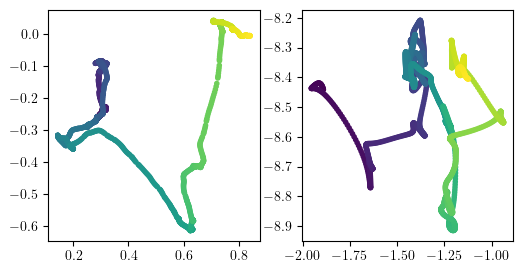

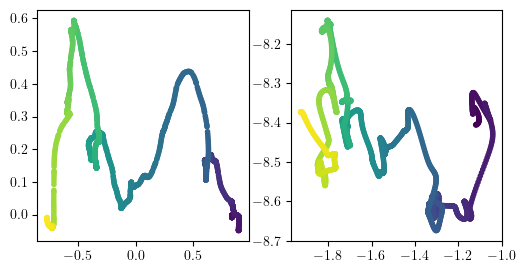

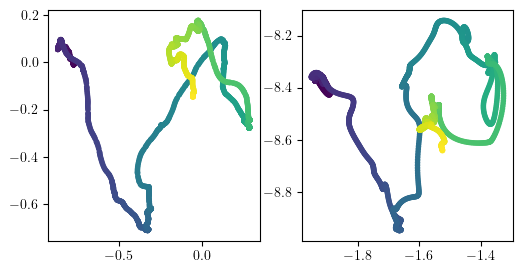

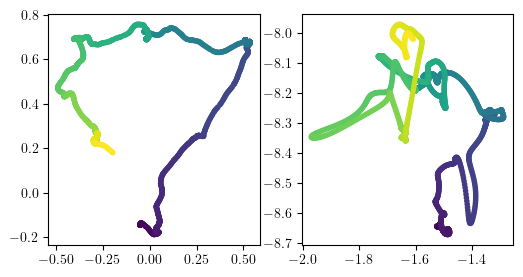

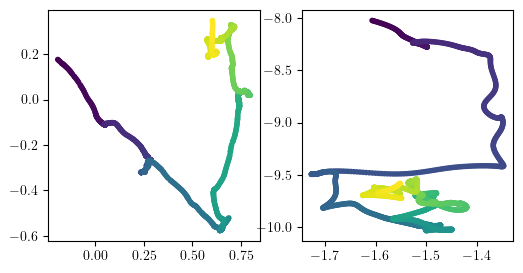

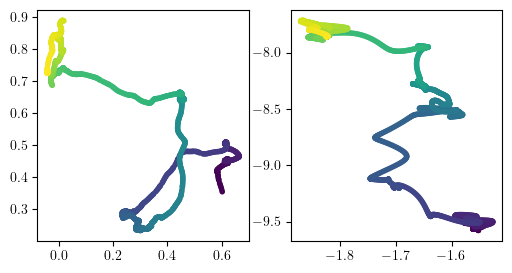

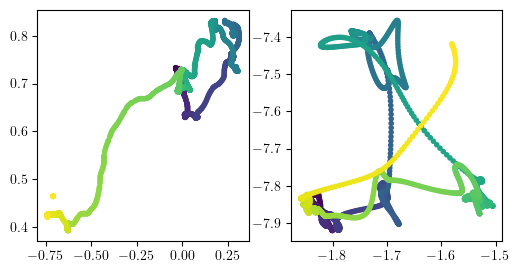

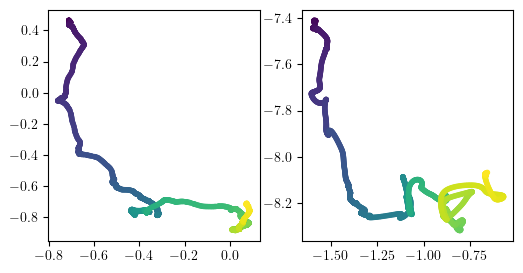

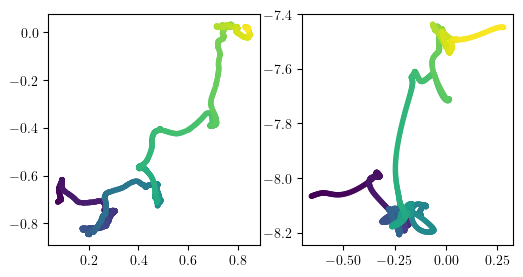

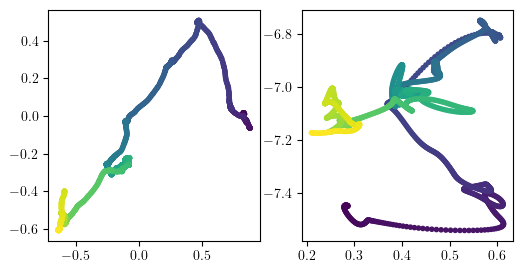

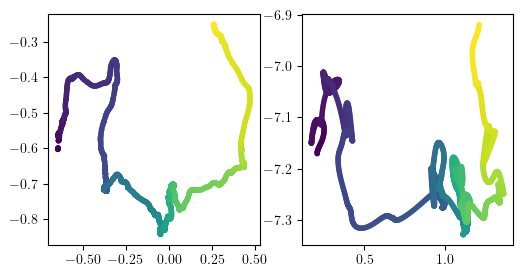

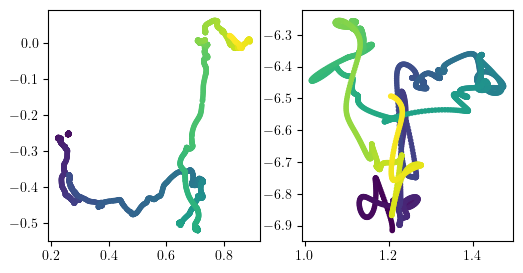

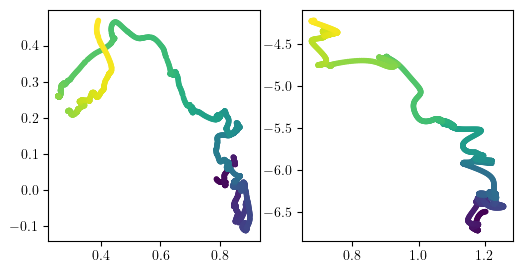

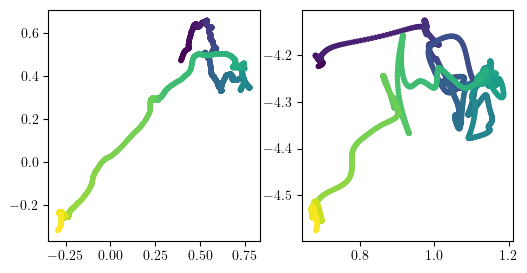

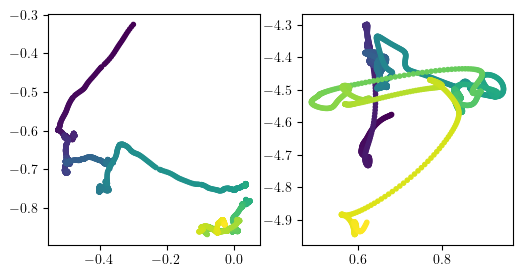

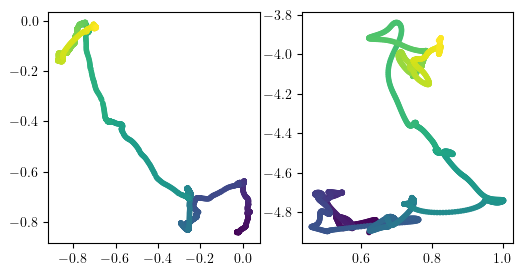

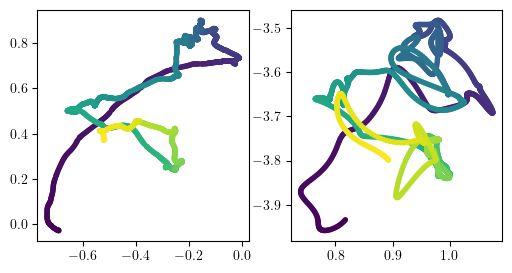

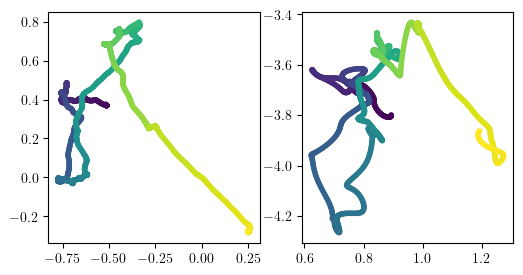

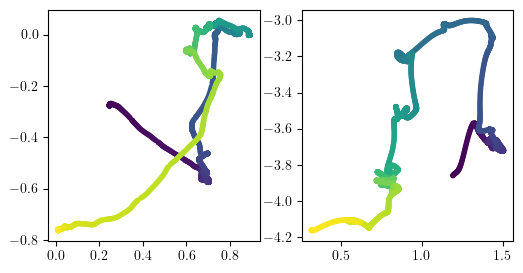

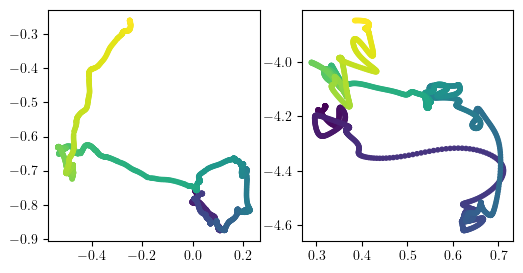

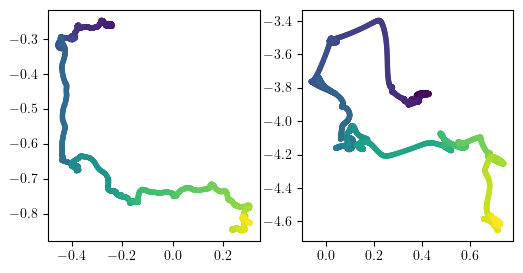

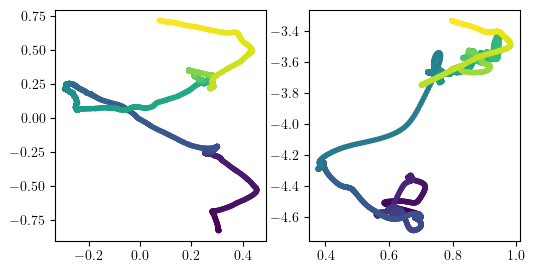

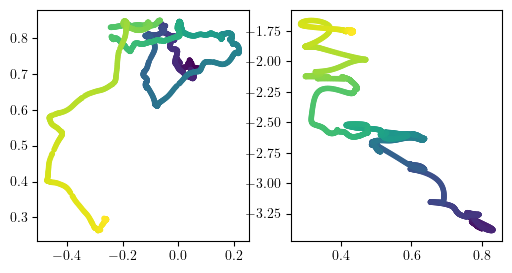

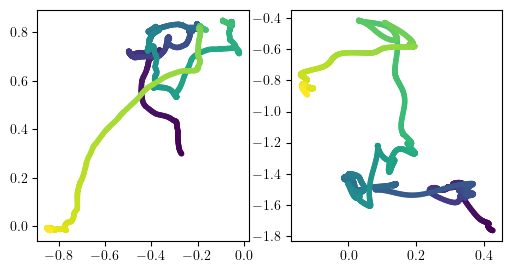

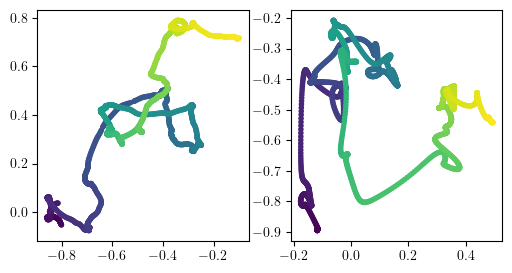

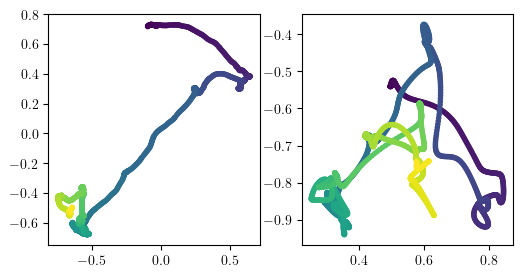

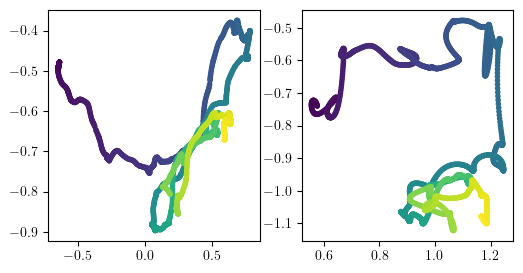

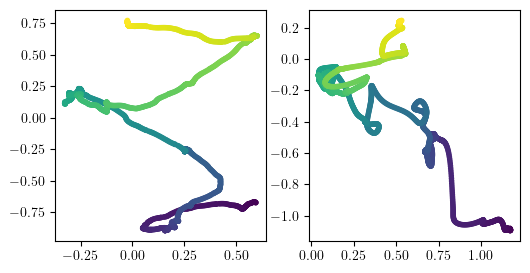

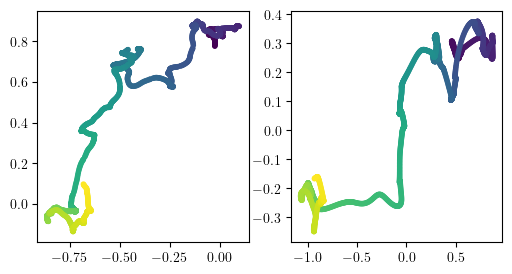

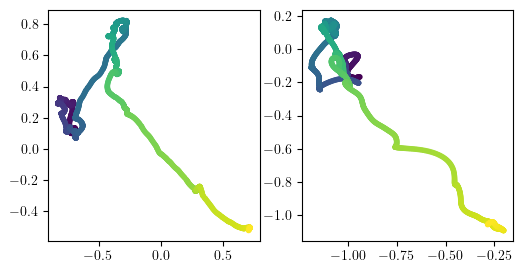

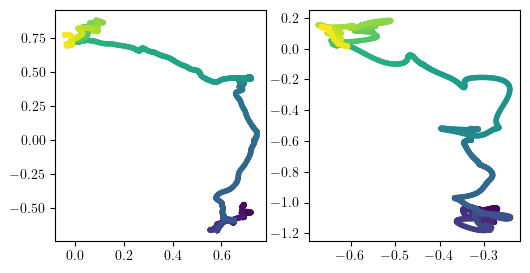

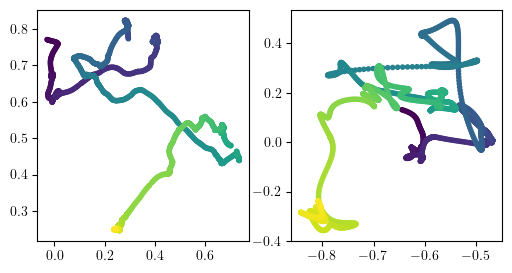

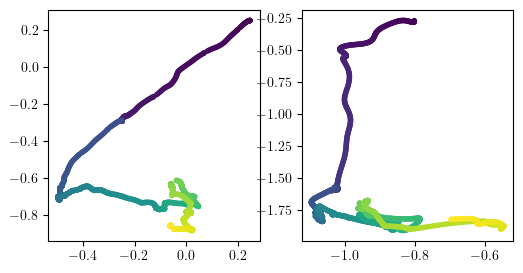

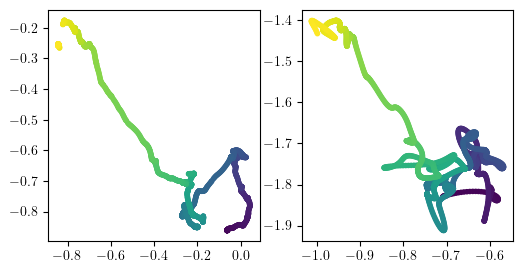

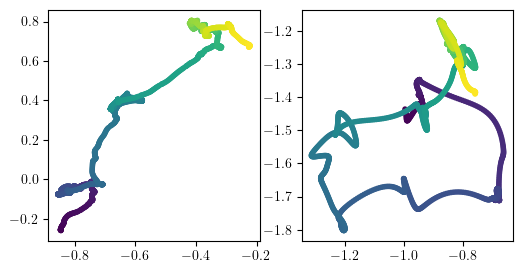

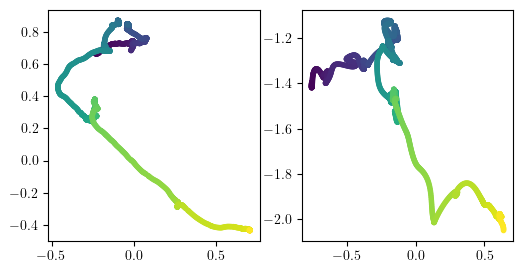

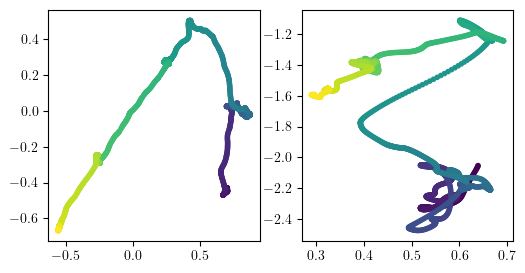

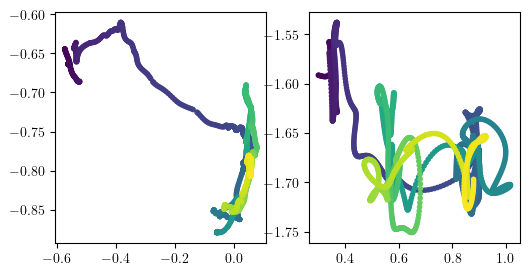

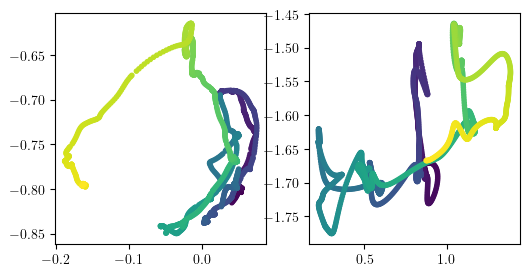

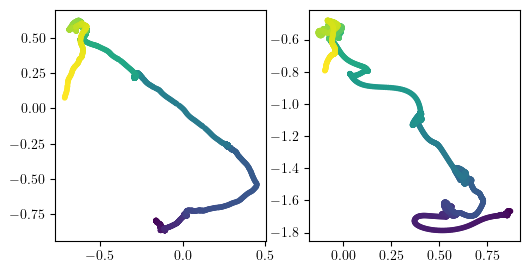

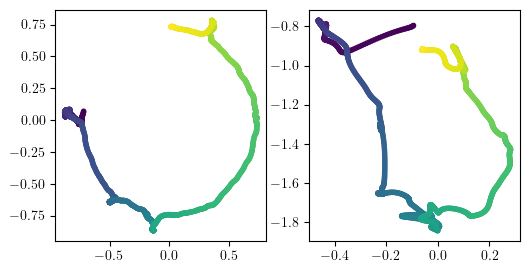

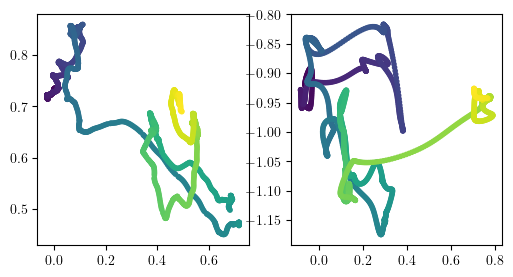

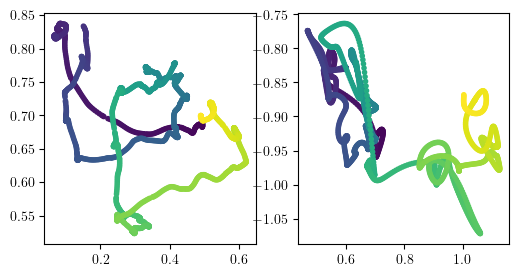

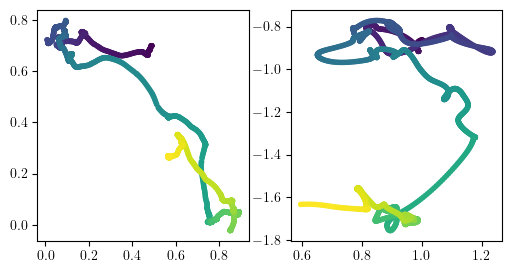

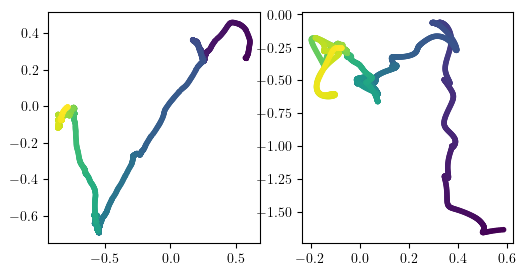

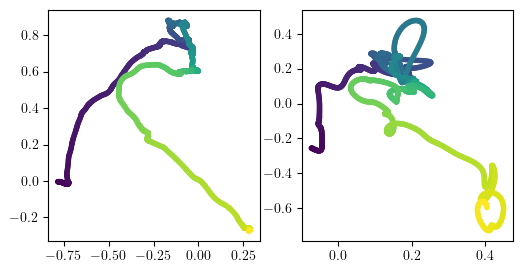

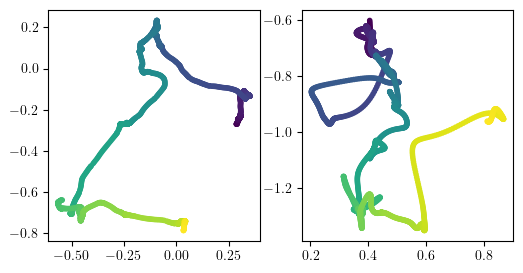

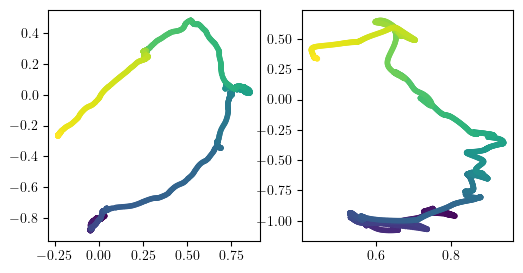

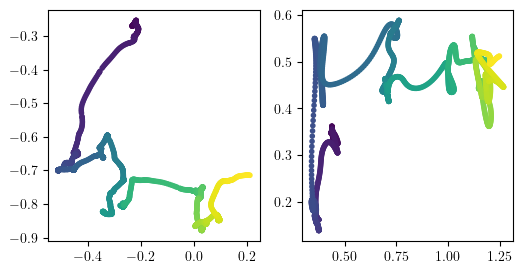

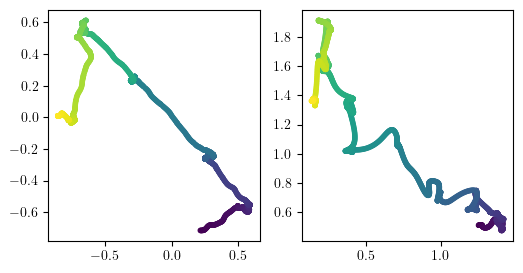

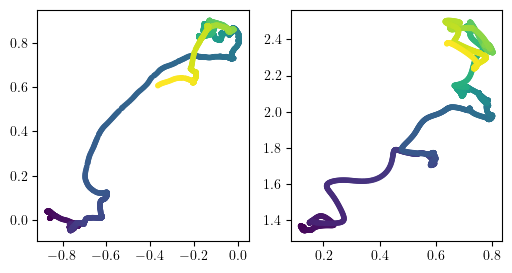

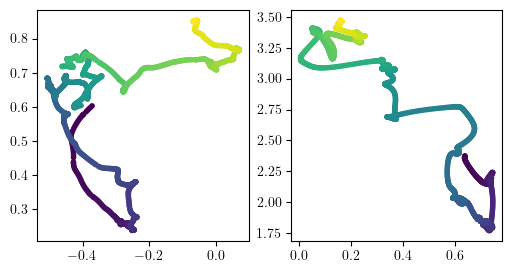

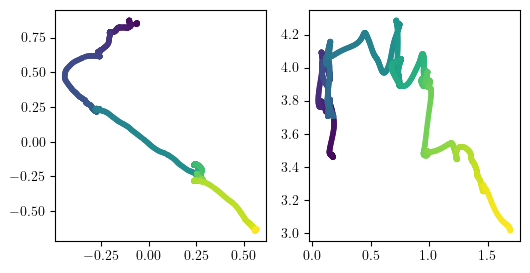

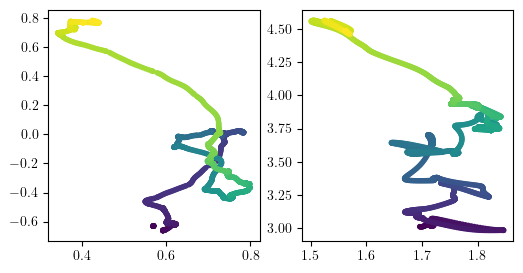

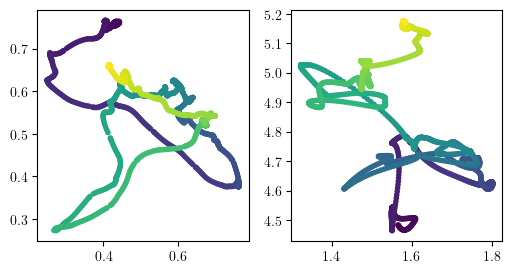

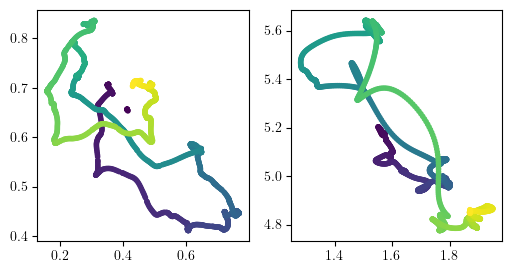

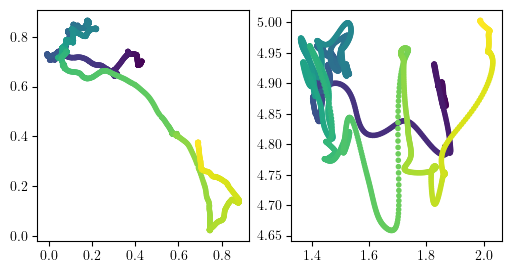

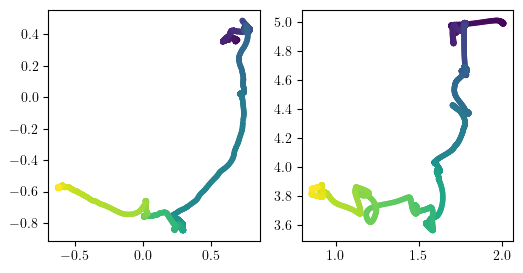

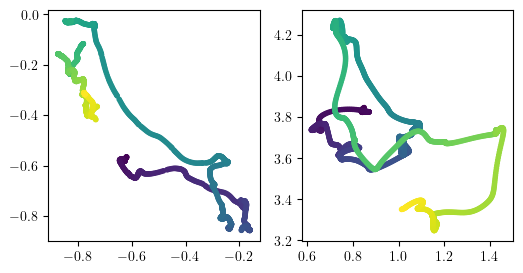

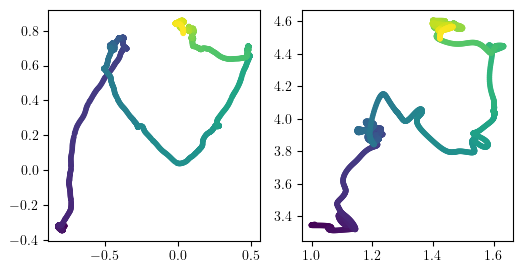

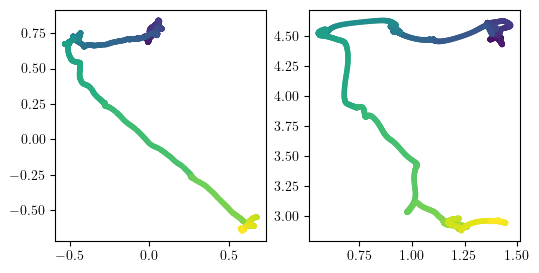

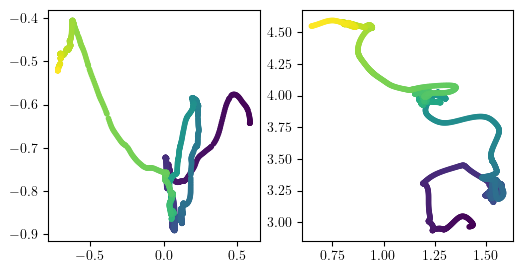

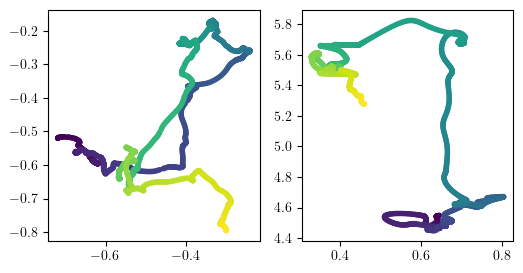

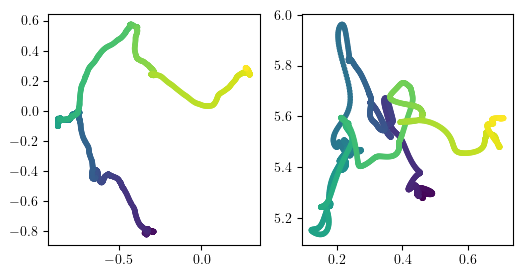

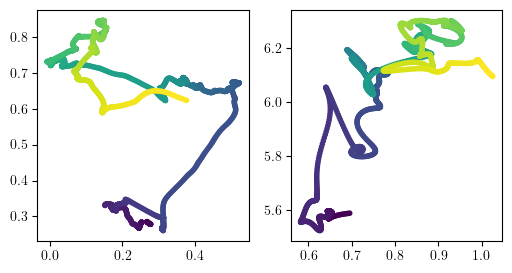

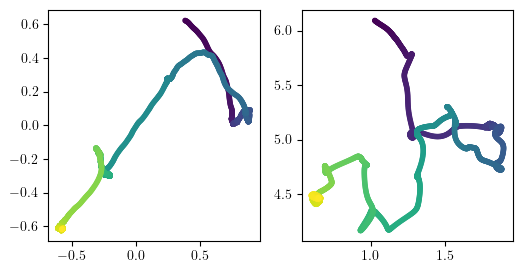

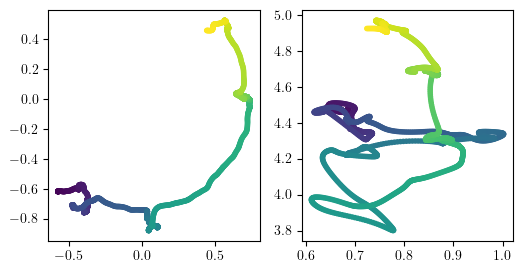

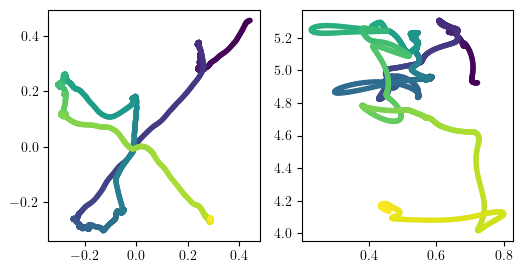

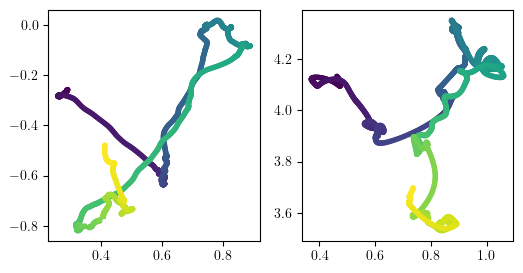

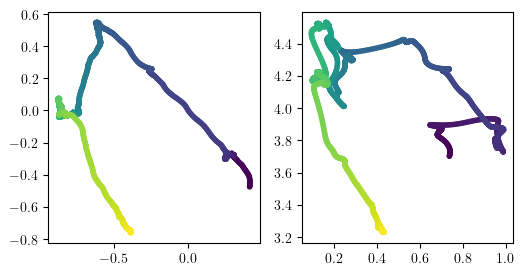

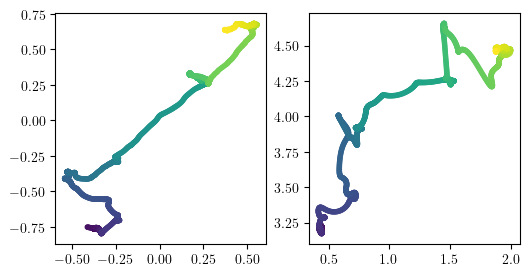

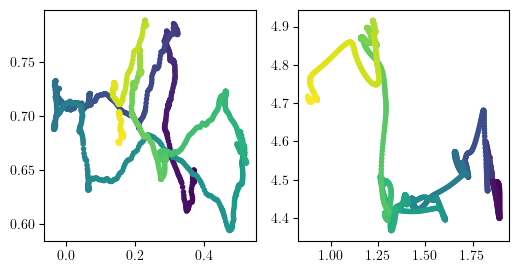

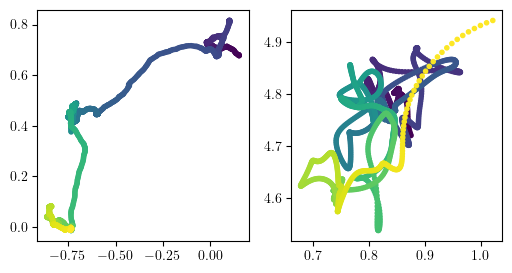

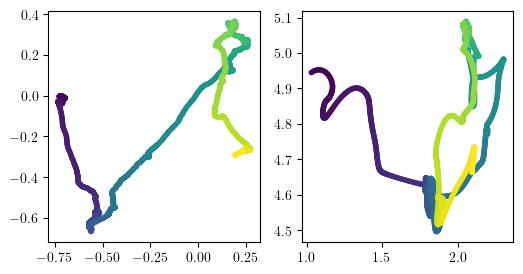

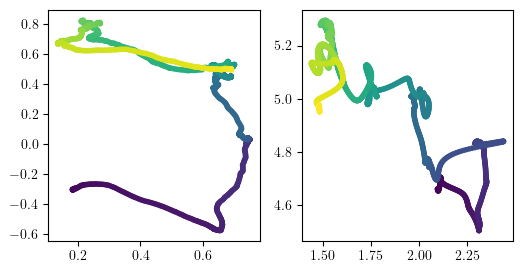

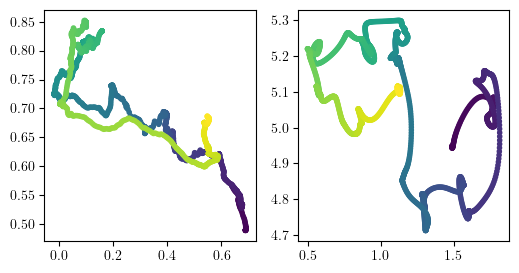

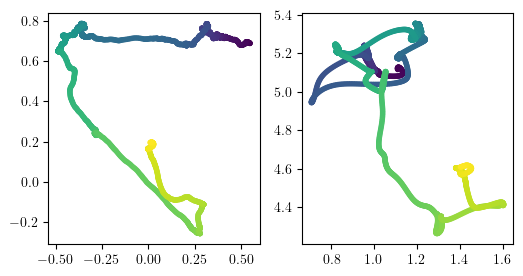

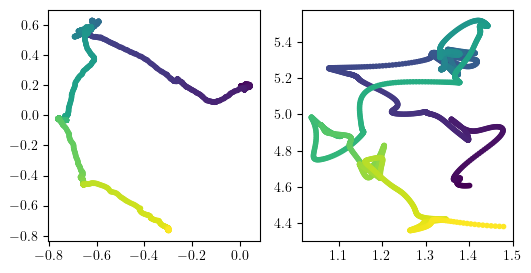

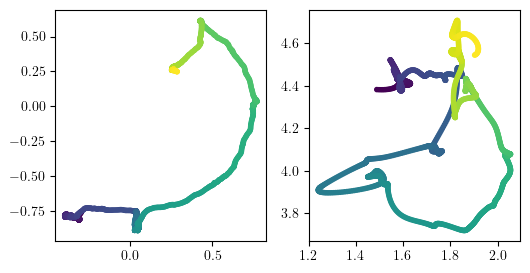

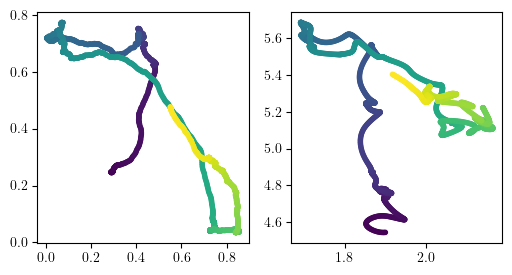

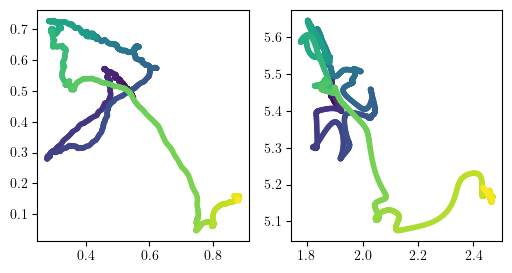

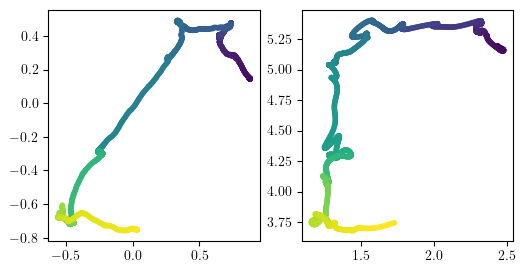

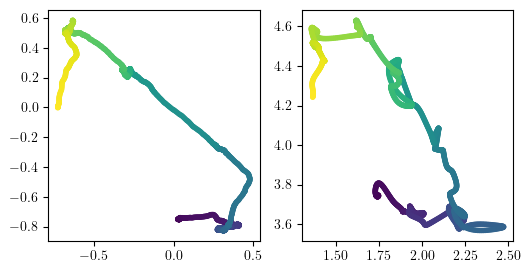

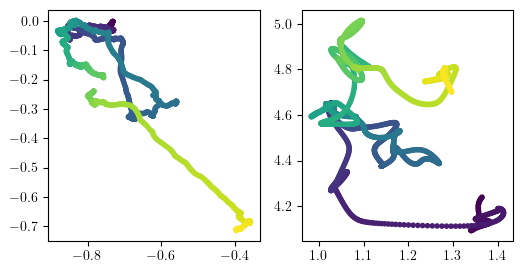

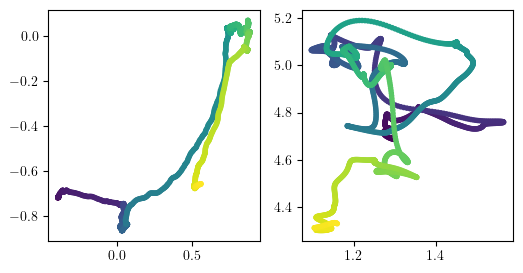

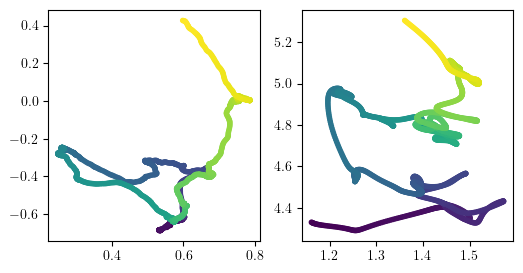

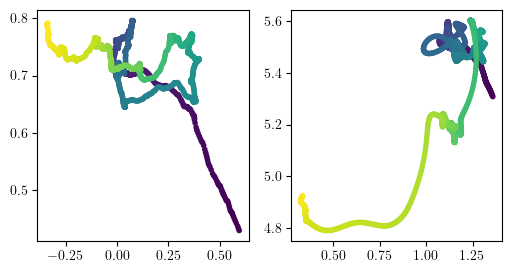

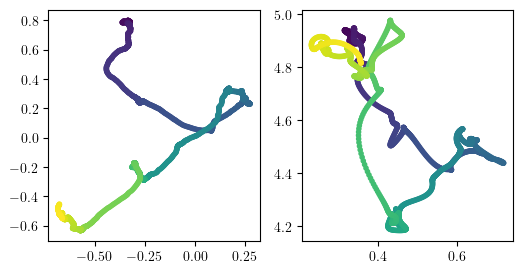

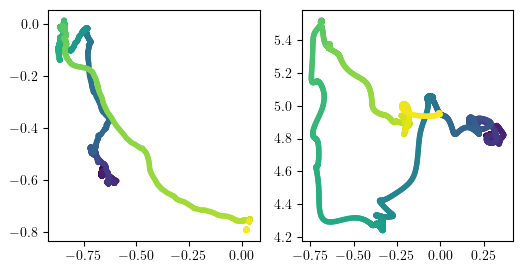

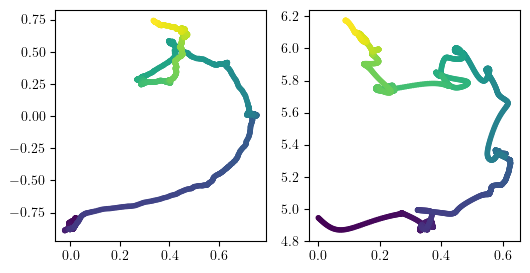

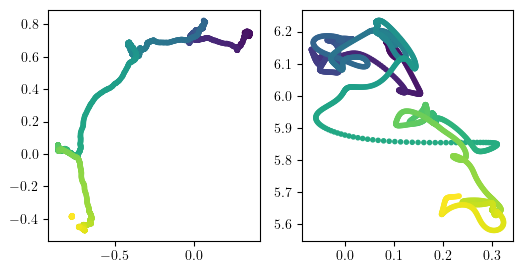

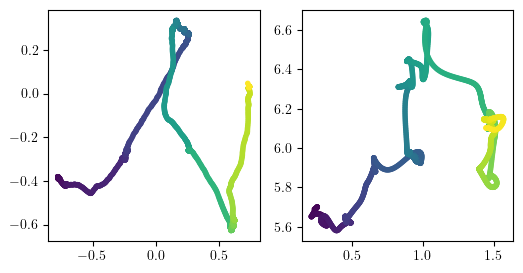

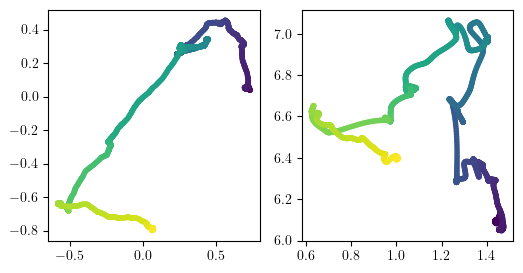

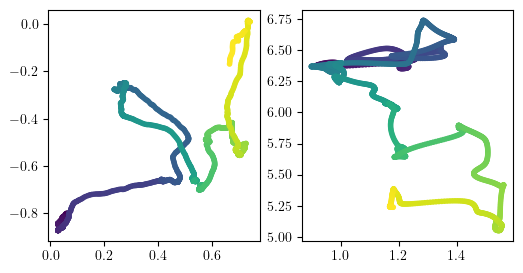

In [13]:
num_seg = lifted.shape[0]//len_seg+1
print(num_seg)

all_original = np.array([original[i*len_seg:(i+1)*len_seg] for i in range(num_seg)])
all_lifted = np.array([lifted[i*len_seg:(i+1)*len_seg] for i in range(num_seg)])
mean_trans_mat = compute_mean_transform_mat(all_original, all_lifted)

uninterp_mismatch = []
for i in range(num_seg):
    original_seg = original[i*len_seg:(i+1)*len_seg]
    lifted_seg = lifted[i*len_seg:(i+1)*len_seg]
    # transform_mat = get_transform_mat(lifted_seg, original_seg)
    recovered_lifted = apply_transform_mat(lifted_seg, [mean_trans_mat])
    uninterp_mismatch.append(score_mismatch(recovered_lifted, original_seg))
    if i < num_seg - 1:
        plt.figure(figsize=(6, 3))
        plt.subplot(1, 2, 1)
        plt.scatter(original_seg[:, 0], original_seg[:, 1], marker='.', color=colors)
        plt.subplot(1, 2, 2)
        plt.scatter(recovered_lifted[:, 0], recovered_lifted[:, 1], marker='.', color=colors)
plt.show()

/home/yyao01/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:119: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


4.1049996684121135


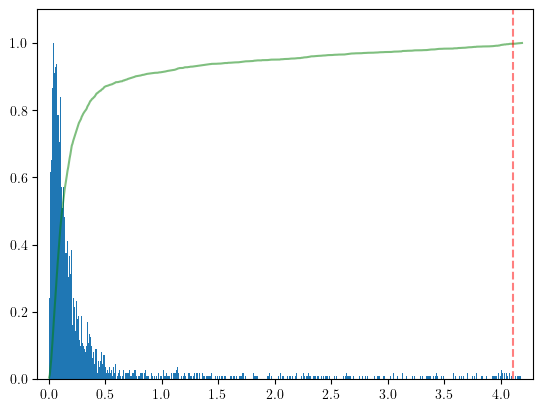

4.1049996684121135


In [18]:
config = ('R', '2', 'REM', 'day2')
lifted = Gardner_coord_temp(interp10=False, config=config, smooth=True)

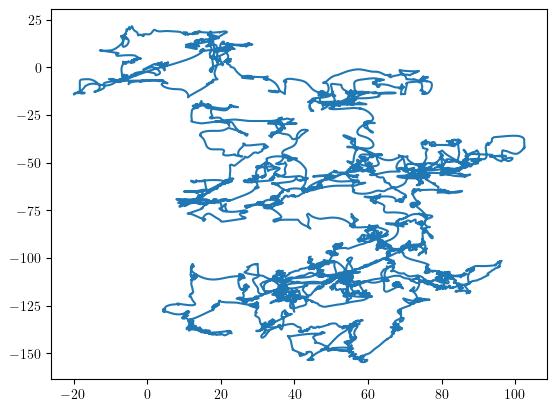

In [19]:
plt.plot(lifted[:, 0], lifted[:, 1])
plt.show()

/home/yyao01/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:119: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


4.324911154163399


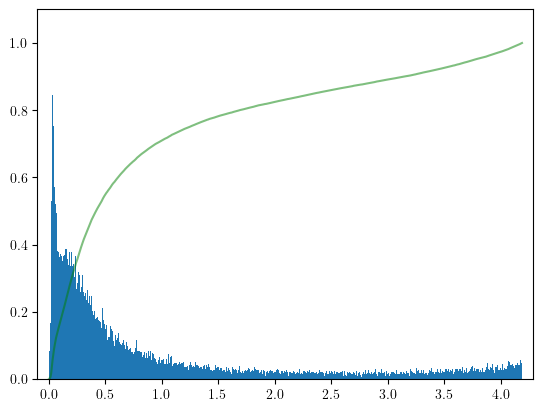

4.324911154163399


In [20]:
config = ('R', '2', 'SWS', 'day2')
lifted = Gardner_coord_temp(interp10=False, config=config, smooth=True)

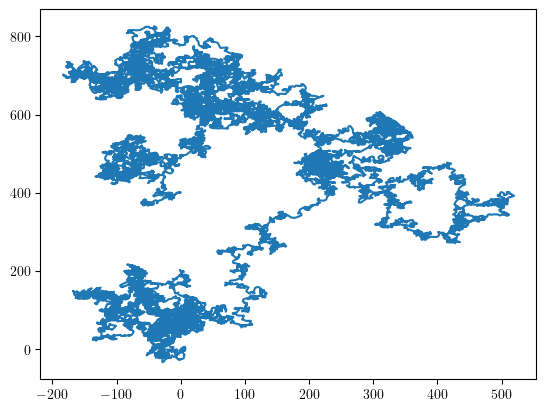

In [21]:
plt.plot(lifted[:, 0], lifted[:, 1])
plt.show()